<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Hierarchical_Clustering_Spotify_Songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [5]:
import pandas as pd
path="/content/drive/MyDrive/ML_Dataset/Spotify_Songs_Dataset.csv"
df=pd.read_csv(path)
df.head(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
#  Select features
X = df[['danceability', 'energy']].dropna()

In [7]:
#  Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
#  Reduce data size to avoid crash
df = df.sample(n=500, random_state=42)

In [10]:
#  Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

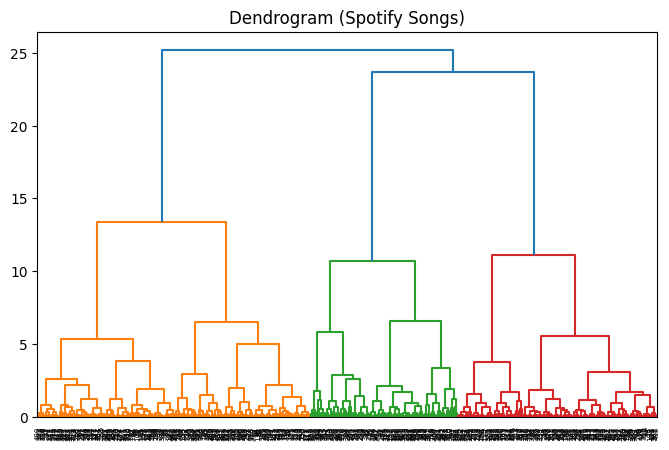

In [11]:
plt.figure(figsize=(8,5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z)
plt.title('Dendrogram (Spotify Songs)')
plt.show()

In [12]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters = hc.fit_predict(X_scaled)

In [13]:
df['Cluster'] = clusters
print(df.head())

        Unnamed: 0                track_id                     artists  \
113186      113186  6KwkVtXm8OUp2XffN5k7lY            Hillsong Worship   
42819        42819  2dp5I5MJ8bQQHDoFaNRFtX                Internal Rot   
59311        59311  5avw06usmFkFrPjX8NxC40  Zhoobin Askarieh;Ali Sasha   
91368        91368  75hT0hvlESnDJstem0JgyR                 Bryan Adams   
61000        61000  4bY2oZGA5Br3pTE1Jd1IfY                  Nogizaka46   

                             album_name             track_name  popularity  \
113186                    No Other Name          No Other Name          50   
42819                    Grieving Birth         Failed Organum          11   
59311              Noise A Noise 20.4-1  Save the Trees, Pt. 1           0   
91368   All I Want For Christmas Is You        Merry Christmas           0   
61000                        バレッタ TypeD                  月の大きさ          57   

        duration_ms  explicit  danceability  energy  ...  mode  speechiness  \
113186 

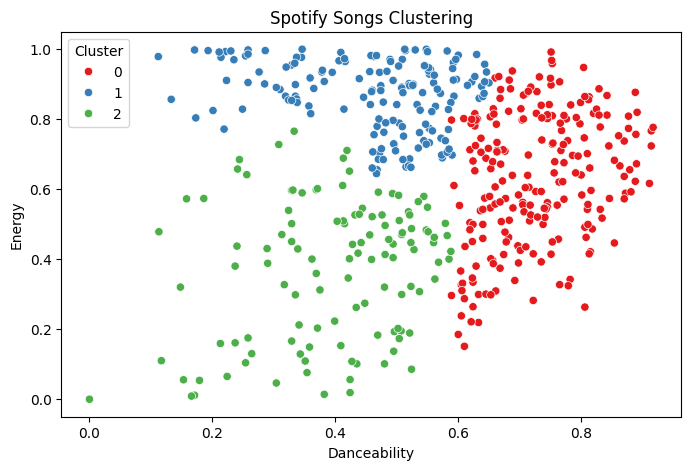

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(x='danceability', y='energy', hue='Cluster', data=df, palette='Set1')
plt.title('Spotify Songs Clustering')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.show()